<a href="https://colab.research.google.com/github/Sonamgitdata/IIT-MAndi-Deep-learning/blob/main/Assignment1_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Downloading: adult.data
Downloaded: adult.data
Downloading: adult.test
Downloaded: adult.test

Training rows: 32561
Testing rows : 16281

After removing missing values:
Training: 30162
Testing : 15060

Training examples: 30162
Testing examples : 15060

Encoded training shape: (30162, 104)
Encoded testing shape : (15060, 104)

Numerical encoded indices: [0, 8, 25, 60, 61, 62]

FEATURE SCALE COMPARISON
Age                  | Raw:        17.00 -        90.00 | Scaled: 0.00 - 1.00
fnlwgt               | Raw:     13769.00 -   1484705.00 | Scaled: 0.00 - 1.00
Education Number     | Raw:         1.00 -        16.00 | Scaled: 0.00 - 1.00
Capital Gain         | Raw:         0.00 -     99999.00 | Scaled: 0.00 - 1.00
Capital Loss         | Raw:         0.00 -      4356.00 | Scaled: 0.00 - 1.00
Hours per Week       | Raw:         1.00 -        99.00 | Scaled: 0.00 - 1.00

TRAINING: RAW DATA
Iteration:   100 | Loss: 0.645427 | |dW1|: 0.000000e+00
Iteration:   200 | Loss: 0.619967 | |dW1|: 0.000000e

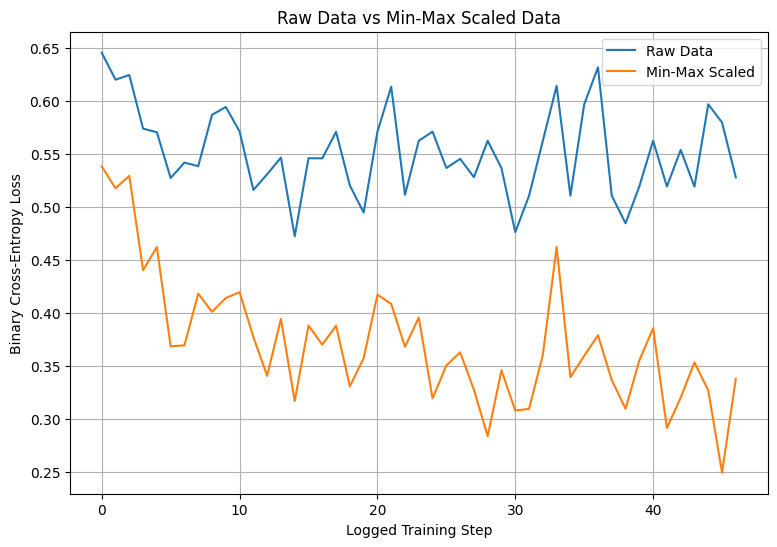

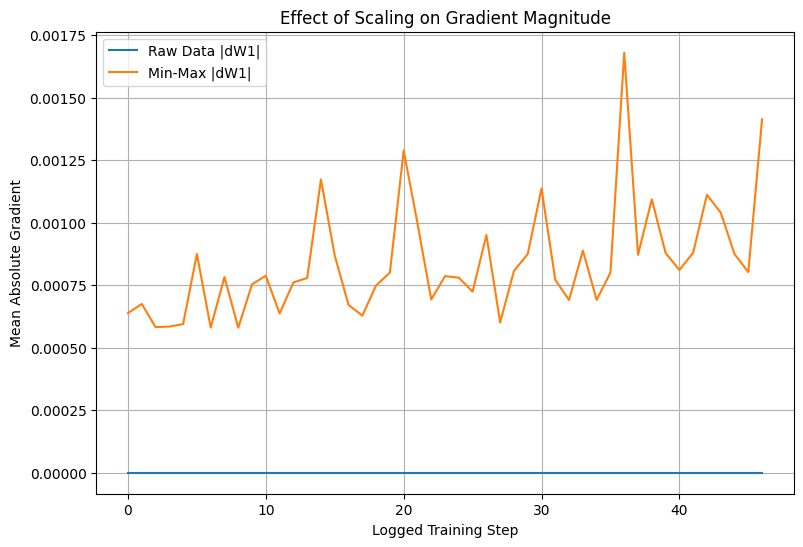


INTERPRETATION

The experiment trains the same NumPy neural network twice.

Experiment 1:
    Raw numerical features are used.

Experiment 2:
    Numerical features are transformed using Min-Max scaling.

The purpose is to investigate how different feature scales
affect optimization and gradient magnitudes.

For example:

    Age:
        usually has values in the tens.

    Capital Gain:
        can have values in the thousands or tens of thousands.

Without scaling, large-valued features can produce larger
contributions to the weight gradients.

With Min-Max scaling, numerical features are transformed
to approximately the same [0, 1] range.

This generally makes gradient updates more balanced and
can make neural-network training more stable.



In [2]:
"""
===============================================================
Question 1.2: Importance of Pre-Processing
===============================================================

Dataset:
    UCI Adult / Census Income Dataset

Task:
    Train the same NumPy-only neural network twice:

    Experiment 1:
        Use raw numerical features.

    Experiment 2:
        Apply Min-Max scaling to numerical features.

Goal:
    Compare:
        - Training loss
        - Test accuracy
        - Gradient magnitudes
        - Training stability

Important:
    No PyTorch
    No TensorFlow
    No Keras
    No Scikit-learn
    No Pandas

Only:
    NumPy + Python standard library

===============================================================
"""

import numpy as np
import urllib.request
import matplotlib.pyplot as plt


# =============================================================
# 1. CONFIGURATION
# =============================================================

SEED = 42

LEARNING_RATE = 0.01
BATCH_SIZE = 128
EPOCHS = 20

HIDDEN_1 = 64
HIDDEN_2 = 32

PRINT_EVERY = 100

rng = np.random.default_rng(SEED)


# =============================================================
# 2. UCI ADULT DATASET URL
# =============================================================

TRAIN_URL = (
    "https://archive.ics.uci.edu/"
    "ml/machine-learning-databases/adult/adult.data"
)

TEST_URL = (
    "https://archive.ics.uci.edu/"
    "ml/machine-learning-databases/adult/adult.test"
)


# =============================================================
# 3. DOWNLOAD DATA
# =============================================================

def download_file(url, filename):
    """
    Download a file from the UCI repository.

    Parameters
    ----------
    url : str
        URL of the dataset.

    filename : str
        Local filename where the data will be saved.
    """

    print("Downloading:", filename)

    urllib.request.urlretrieve(url, filename)

    print("Downloaded:", filename)


download_file(TRAIN_URL, "adult.data")
download_file(TEST_URL, "adult.test")


# =============================================================
# 4. DATASET COLUMN NAMES
# =============================================================

COLUMNS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country"
]


# =============================================================
# 5. NUMERICAL FEATURES
# =============================================================

# These are the numerical features in the Adult dataset.

NUMERIC_COLUMNS = [
    0,   # age
    2,   # fnlwgt
    4,   # education_num
    10,  # capital_gain
    11,  # capital_loss
    12   # hours_per_week
]


# =============================================================
# 6. READ RAW FILE
# =============================================================

def read_file(filename, is_test=False):
    """
    Read the Adult dataset text file.

    The test file contains a header/comment line that
    should be skipped.

    Returns
    -------
    rows : list
        List containing dataset rows.
    """

    rows = []

    with open(
        filename,
        "r",
        encoding="utf-8"
    ) as file:

        lines = file.readlines()


    for line_number, line in enumerate(lines):

        line = line.strip()

        # Skip empty lines.
        if not line:
            continue

        # adult.test contains a first line describing
        # the dataset.
        if is_test and line_number == 0:
            continue

        parts = [
            value.strip()
            for value in line.split(",")
        ]

        # 14 features + 1 target
        if len(parts) != 15:
            continue

        rows.append(parts)

    return rows


train_rows = read_file(
    "adult.data",
    is_test=False
)

test_rows = read_file(
    "adult.test",
    is_test=True
)


print()
print("Training rows:", len(train_rows))
print("Testing rows :", len(test_rows))


# =============================================================
# 7. REMOVE MISSING VALUES
# =============================================================

def remove_missing(rows):
    """
    Remove rows containing '?'.

    The UCI Adult dataset contains missing values
    represented by '?'.
    """

    cleaned = []

    for row in rows:

        if "?" not in row:
            cleaned.append(row)

    return cleaned


train_rows = remove_missing(train_rows)
test_rows = remove_missing(test_rows)


print()
print("After removing missing values:")
print("Training:", len(train_rows))
print("Testing :", len(test_rows))


# =============================================================
# 8. SEPARATE FEATURES AND TARGET
# =============================================================

def split_data(rows):
    """
    Separate input features and income target.

    Target:
        <=50K  -> 0
        >50K   -> 1
    """

    X = []
    y = []

    for row in rows:

        # First 14 values are features.
        X.append(row[:14])

        # Last value is income.
        target = row[14]

        # Remove '.' appearing in adult.test labels.
        target = target.replace(".", "").strip()

        if target == ">50K":
            y.append(1)

        else:
            y.append(0)

    return X, np.array(y, dtype=np.float64)


X_train_raw, y_train = split_data(train_rows)

X_test_raw, y_test = split_data(test_rows)


print()
print("Training examples:", len(X_train_raw))
print("Testing examples :", len(X_test_raw))


# =============================================================
# 9. BUILD CATEGORICAL DICTIONARIES
# =============================================================

def build_categories(X):
    """
    Build possible values for every categorical feature.

    IMPORTANT:
        Categories are learned from training data only.
    """

    categories = {}

    for column in range(14):

        if column in NUMERIC_COLUMNS:
            continue

        values = sorted(
            set(
                row[column]
                for row in X
            )
        )

        categories[column] = values

    return categories


categories = build_categories(
    X_train_raw
)


# =============================================================
# 10. ONE-HOT ENCODING
# =============================================================

def encode_features(X, categories):
    """
    Convert categorical features to one-hot vectors.

    Numerical features remain numerical.

    Example:

        sex = Male

    becomes something like:

        [0, 1]
    """

    encoded = []

    for row in X:

        new_row = []

        for column, value in enumerate(row):

            # -------------------------------------------------
            # Numerical feature
            # -------------------------------------------------

            if column in NUMERIC_COLUMNS:

                new_row.append(
                    float(value)
                )

            # -------------------------------------------------
            # Categorical feature
            # -------------------------------------------------

            else:

                possible_values = categories[column]

                for category in possible_values:

                    if value == category:
                        new_row.append(1.0)

                    else:
                        new_row.append(0.0)

        encoded.append(new_row)

    return np.array(
        encoded,
        dtype=np.float64
    )


X_train = encode_features(
    X_train_raw,
    categories
)

X_test = encode_features(
    X_test_raw,
    categories
)


print()
print("Encoded training shape:", X_train.shape)
print("Encoded testing shape :", X_test.shape)


# =============================================================
# 11. IDENTIFY NUMERICAL COLUMNS AFTER ENCODING
# =============================================================

numeric_encoded_indices = []

position = 0

for column in range(14):

    if column in NUMERIC_COLUMNS:

        numeric_encoded_indices.append(
            position
        )

        position += 1

    else:

        position += len(
            categories[column]
        )


print()
print(
    "Numerical encoded indices:",
    numeric_encoded_indices
)


# =============================================================
# 12. CREATE TWO COPIES OF THE DATA
# =============================================================

# Experiment 1:
# Original numerical values.

X_train_raw_scale = X_train.copy()

X_test_raw_scale = X_test.copy()


# Experiment 2:
# Will contain Min-Max scaled values.

X_train_minmax = X_train.copy()

X_test_minmax = X_test.copy()


# =============================================================
# 13. MIN-MAX SCALING
# =============================================================

def min_max_scale(
    X_train,
    X_test,
    columns
):
    """
    Apply Min-Max scaling.

    Formula:

        X_scaled =
            (X - X_min) /
            (X_max - X_min)

    The minimum and maximum values are calculated
    ONLY from the training data.

    This prevents information from the test set
    leaking into training.
    """

    X_train_scaled = X_train.copy()

    X_test_scaled = X_test.copy()


    for column in columns:

        minimum = np.min(
            X_train[:, column]
        )

        maximum = np.max(
            X_train[:, column]
        )

        denominator = maximum - minimum


        # Prevent division by zero.
        if denominator == 0:
            denominator = 1.0


        X_train_scaled[:, column] = (
            X_train[:, column] - minimum
        ) / denominator


        X_test_scaled[:, column] = (
            X_test[:, column] - minimum
        ) / denominator


    return (
        X_train_scaled,
        X_test_scaled
    )


(
    X_train_minmax,
    X_test_minmax
) = min_max_scale(
    X_train,
    X_test,
    numeric_encoded_indices
)


# =============================================================
# 14. DISPLAY FEATURE SCALE DIFFERENCE
# =============================================================

print()
print("=" * 70)
print("FEATURE SCALE COMPARISON")
print("=" * 70)

for column, name in zip(
    numeric_encoded_indices,
    [
        "Age",
        "fnlwgt",
        "Education Number",
        "Capital Gain",
        "Capital Loss",
        "Hours per Week"
    ]
):

    raw_min = np.min(
        X_train_raw_scale[:, column]
    )

    raw_max = np.max(
        X_train_raw_scale[:, column]
    )

    scaled_min = np.min(
        X_train_minmax[:, column]
    )

    scaled_max = np.max(
        X_train_minmax[:, column]
    )

    print(
        f"{name:20s} | "
        f"Raw: {raw_min:12.2f} - {raw_max:12.2f} | "
        f"Scaled: {scaled_min:.2f} - {scaled_max:.2f}"
    )


# =============================================================
# 15. RELU
# =============================================================

def relu(Z):
    """
    ReLU activation:

        ReLU(Z) = max(0, Z)
    """

    return np.maximum(
        0,
        Z
    )


def relu_derivative(Z):
    """
    Derivative of ReLU.
    """

    return (
        Z > 0
    ).astype(np.float64)


# =============================================================
# 16. SIGMOID
# =============================================================

def sigmoid(Z):
    """
    Sigmoid activation function.
    """

    Z = np.clip(
        Z,
        -500,
        500
    )

    return 1.0 / (
        1.0 + np.exp(-Z)
    )


# =============================================================
# 17. HE INITIALIZATION
# =============================================================

def he_initialization(
    n_input,
    n_output,
    rng
):
    """
    He initialization.

    Standard deviation:

        sqrt(2 / n_input)
    """

    scale = np.sqrt(
        2.0 / n_input
    )

    return (
        rng.standard_normal(
            (n_output, n_input)
        )
        * scale
    )


# =============================================================
# 18. INITIALIZE NETWORK
# =============================================================

def initialize_network(
    input_size,
    hidden_1,
    hidden_2,
    rng
):
    """
    Create weights and biases.

    Architecture:

        Input
          |
        64 neurons
          |
        32 neurons
          |
        1 output
    """

    W1 = he_initialization(
        input_size,
        hidden_1,
        rng
    )

    b1 = np.zeros(
        (hidden_1, 1)
    )


    W2 = he_initialization(
        hidden_1,
        hidden_2,
        rng
    )

    b2 = np.zeros(
        (hidden_2, 1)
    )


    W3 = he_initialization(
        hidden_2,
        1,
        rng
    )

    b3 = np.zeros(
        (1, 1)
    )


    return (
        W1, b1,
        W2, b2,
        W3, b3
    )


# =============================================================
# 19. FORWARD PASS
# =============================================================

def forward(
    X,
    W1, b1,
    W2, b2,
    W3, b3
):
    """
    Forward propagation.

    Layer 1:
        Z1 = W1 X + b1
        A1 = ReLU(Z1)

    Layer 2:
        Z2 = W2 A1 + b2
        A2 = ReLU(Z2)

    Output:
        Z3 = W3 A2 + b3
        A3 = Sigmoid(Z3)
    """

    Z1 = (
        W1 @ X
        + b1
    )

    A1 = relu(Z1)


    Z2 = (
        W2 @ A1
        + b2
    )

    A2 = relu(Z2)


    Z3 = (
        W3 @ A2
        + b3
    )

    A3 = sigmoid(Z3)


    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "A3": A3
    }


    return A3, cache


# =============================================================
# 20. BINARY CROSS ENTROPY
# =============================================================

def binary_cross_entropy(
    y,
    prediction
):
    """
    Binary Cross Entropy loss.
    """

    epsilon = 1e-12

    prediction = np.clip(
        prediction,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        y * np.log(prediction)
        +
        (1 - y)
        * np.log(1 - prediction)
    )

    return loss


# =============================================================
# 21. BACKPROPAGATION
# =============================================================

def backward(
    y,
    cache,
    W2,
    W3
):
    """
    Calculate gradients using the chain rule.
    """

    X = cache["X"]

    Z1 = cache["Z1"]
    A1 = cache["A1"]

    Z2 = cache["Z2"]
    A2 = cache["A2"]

    A3 = cache["A3"]


    m = X.shape[1]


    # ---------------------------------------------------------
    # Output layer
    # ---------------------------------------------------------

    dZ3 = A3 - y

    dW3 = (
        dZ3 @ A2.T
    ) / m

    db3 = np.sum(
        dZ3,
        axis=1,
        keepdims=True
    ) / m


    # ---------------------------------------------------------
    # Hidden layer 2
    # ---------------------------------------------------------

    dA2 = W3.T @ dZ3

    dZ2 = (
        dA2
        * relu_derivative(Z2)
    )

    dW2 = (
        dZ2 @ A1.T
    ) / m

    db2 = np.sum(
        dZ2,
        axis=1,
        keepdims=True
    ) / m


    # ---------------------------------------------------------
    # Hidden layer 1
    # ---------------------------------------------------------

    dA1 = W2.T @ dZ2

    dZ1 = (
        dA1
        * relu_derivative(Z1)
    )

    dW1 = (
        dZ1 @ X.T
    ) / m

    db1 = np.sum(
        dZ1,
        axis=1,
        keepdims=True
    ) / m


    gradients = {
        "dW1": dW1,
        "db1": db1,

        "dW2": dW2,
        "db2": db2,

        "dW3": dW3,
        "db3": db3
    }


    return gradients


# =============================================================
# 22. SGD UPDATE
# =============================================================

def update_parameters(
    W1, b1,
    W2, b2,
    W3, b3,
    gradients,
    learning_rate
):
    """
    Basic SGD update:

        W_new =
            W_old -
            learning_rate * gradient
    """

    W1 -= (
        learning_rate
        * gradients["dW1"]
    )

    b1 -= (
        learning_rate
        * gradients["db1"]
    )


    W2 -= (
        learning_rate
        * gradients["dW2"]
    )

    b2 -= (
        learning_rate
        * gradients["db2"]
    )


    W3 -= (
        learning_rate
        * gradients["dW3"]
    )

    b3 -= (
        learning_rate
        * gradients["db3"]
    )


    return (
        W1, b1,
        W2, b2,
        W3, b3
    )


# =============================================================
# 23. GRADIENT MAGNITUDE
# =============================================================

def calculate_gradient_magnitudes(
    gradients
):
    """
    Calculate average absolute magnitude
    of each gradient matrix.

    This is important for Question 1.2.

    We want to observe how scaling changes
    the magnitude of the gradients.
    """

    magnitudes = {}

    for name, gradient in gradients.items():

        magnitudes[name] = np.mean(
            np.abs(gradient)
        )

    return magnitudes


# =============================================================
# 24. PREDICTION
# =============================================================

def predict(
    X,
    W1, b1,
    W2, b2,
    W3, b3
):
    """
    Generate binary predictions.
    """

    probabilities, _ = forward(
        X,
        W1, b1,
        W2, b2,
        W3, b3
    )

    predictions = (
        probabilities >= 0.5
    ).astype(np.float64)

    return predictions


# =============================================================
# 25. ACCURACY
# =============================================================

def accuracy(
    y_true,
    y_pred
):
    """
    Classification accuracy.
    """

    return np.mean(
        y_true.flatten()
        ==
        y_pred.flatten()
    )


# =============================================================
# 26. TRAIN FUNCTION
# =============================================================

def train_model(
    X_train,
    y_train,
    learning_rate,
    batch_size,
    epochs,
    seed,
    experiment_name
):
    """
    Train one complete neural network.

    This function is used twice:

        Experiment 1:
            Raw data

        Experiment 2:
            Min-Max scaled data
    """

    print()
    print("=" * 70)
    print(
        "TRAINING:",
        experiment_name
    )
    print("=" * 70)


    local_rng = np.random.default_rng(
        seed
    )


    # ---------------------------------------------------------
    # Initialize network
    # ---------------------------------------------------------

    (
        W1, b1,
        W2, b2,
        W3, b3
    ) = initialize_network(
        X_train.shape[1],
        HIDDEN_1,
        HIDDEN_2,
        local_rng
    )


    n_samples = X_train.shape[0]

    y_matrix = y_train.reshape(
        1,
        -1
    )


    loss_history = []

    gradient_history = []

    iteration = 0


    # ---------------------------------------------------------
    # Epoch loop
    # ---------------------------------------------------------

    for epoch in range(
        epochs
    ):

        # Shuffle data.
        indices = local_rng.permutation(
            n_samples
        )

        X_shuffled = X_train[
            indices
        ]

        y_shuffled = y_matrix[
            :,
            indices
        ]


        # -----------------------------------------------------
        # Mini-batch loop
        # -----------------------------------------------------

        for start in range(
            0,
            n_samples,
            batch_size
        ):

            end = min(
                start + batch_size,
                n_samples
            )


            X_batch = X_shuffled[
                start:end
            ]

            y_batch = y_shuffled[
                :,
                start:end
            ]


            # Network expects:
            #
            # features x samples

            X_batch = X_batch.T


            # -------------------------------------------------
            # Forward
            # -------------------------------------------------

            prediction, cache = forward(
                X_batch,

                W1, b1,
                W2, b2,
                W3, b3
            )


            # -------------------------------------------------
            # Loss
            # -------------------------------------------------

            loss = binary_cross_entropy(
                y_batch,
                prediction
            )


            # -------------------------------------------------
            # Backpropagation
            # -------------------------------------------------

            gradients = backward(
                y_batch,
                cache,
                W2,
                W3
            )


            # -------------------------------------------------
            # Record gradient magnitude
            # -------------------------------------------------

            gradient_magnitudes = (
                calculate_gradient_magnitudes(
                    gradients
                )
            )


            # -------------------------------------------------
            # SGD
            # -------------------------------------------------

            (
                W1, b1,
                W2, b2,
                W3, b3
            ) = update_parameters(
                W1, b1,
                W2, b2,
                W3, b3,
                gradients,
                learning_rate
            )


            iteration += 1


            # -------------------------------------------------
            # Save information every 100 iterations.
            # -------------------------------------------------

            if iteration % PRINT_EVERY == 0:

                loss_history.append(
                    loss
                )

                gradient_history.append(
                    gradient_magnitudes
                )


                print(
                    f"Iteration: {iteration:5d} | "
                    f"Loss: {loss:.6f} | "
                    f"|dW1|: {gradient_magnitudes['dW1']:.6e}"
                )


    # ---------------------------------------------------------
    # Return everything needed for analysis.
    # ---------------------------------------------------------

    parameters = {
        "W1": W1,
        "b1": b1,

        "W2": W2,
        "b2": b2,

        "W3": W3,
        "b3": b3
    }


    return (
        parameters,
        loss_history,
        gradient_history
    )


# =============================================================
# 27. EXPERIMENT 1 — RAW DATA
# =============================================================

(
    raw_parameters,
    raw_losses,
    raw_gradients
) = train_model(
    X_train_raw_scale,
    y_train,

    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,

    seed=SEED,

    experiment_name="RAW DATA"
)


# =============================================================
# 28. EXPERIMENT 2 — MIN-MAX SCALED DATA
# =============================================================

(
    scaled_parameters,
    scaled_losses,
    scaled_gradients
) = train_model(
    X_train_minmax,
    y_train,

    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,

    seed=SEED,

    experiment_name="MIN-MAX SCALED DATA"
)


# =============================================================
# 29. TEST RAW MODEL
# =============================================================

raw_predictions = predict(
    X_test_raw_scale.T,

    raw_parameters["W1"],
    raw_parameters["b1"],

    raw_parameters["W2"],
    raw_parameters["b2"],

    raw_parameters["W3"],
    raw_parameters["b3"]
)


raw_accuracy = accuracy(
    y_test,
    raw_predictions
)


# =============================================================
# 30. TEST SCALED MODEL
# =============================================================

scaled_predictions = predict(
    X_test_minmax.T,

    scaled_parameters["W1"],
    scaled_parameters["b1"],

    scaled_parameters["W2"],
    scaled_parameters["b2"],

    scaled_parameters["W3"],
    scaled_parameters["b3"]
)


scaled_accuracy = accuracy(
    y_test,
    scaled_predictions
)


# =============================================================
# 31. PRINT FINAL COMPARISON
# =============================================================

print()
print()
print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)

print(
    f"Raw Data Accuracy       : "
    f"{raw_accuracy * 100:.2f}%"
)

print(
    f"Min-Max Scaled Accuracy : "
    f"{scaled_accuracy * 100:.2f}%"
)

print("=" * 70)


# =============================================================
# 32. COMPARE FINAL GRADIENTS
# =============================================================

print()
print("=" * 70)
print("GRADIENT COMPARISON")
print("=" * 70)

gradient_names = [
    "dW1",
    "db1",
    "dW2",
    "db2",
    "dW3",
    "db3"
]


print(
    f"{'Gradient':10s} "
    f"{'Raw Data':>20s} "
    f"{'Min-Max':>20s}"
)

print("-" * 55)


for name in gradient_names:

    raw_value = raw_gradients[-1][name]

    scaled_value = scaled_gradients[-1][name]

    print(
        f"{name:10s} "
        f"{raw_value:20.8e} "
        f"{scaled_value:20.8e}"
    )


# =============================================================
# 33. PLOT TRAINING LOSS
# =============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    raw_losses,
    label="Raw Data"
)


plt.plot(
    scaled_losses,
    label="Min-Max Scaled"
)


plt.xlabel(
    "Logged Training Step"
)

plt.ylabel(
    "Binary Cross-Entropy Loss"
)

plt.title(
    "Raw Data vs Min-Max Scaled Data"
)

plt.legend()

plt.grid(True)

plt.show()


# =============================================================
# 34. PLOT GRADIENT MAGNITUDE
# =============================================================

raw_dW1 = [
    item["dW1"]
    for item in raw_gradients
]

scaled_dW1 = [
    item["dW1"]
    for item in scaled_gradients
]


plt.figure(
    figsize=(9, 6)
)


plt.plot(
    raw_dW1,
    label="Raw Data |dW1|"
)


plt.plot(
    scaled_dW1,
    label="Min-Max |dW1|"
)


plt.xlabel(
    "Logged Training Step"
)

plt.ylabel(
    "Mean Absolute Gradient"
)

plt.title(
    "Effect of Scaling on Gradient Magnitude"
)

plt.legend()

plt.grid(True)

plt.show()


# =============================================================
# 35. FINAL INTERPRETATION
# =============================================================

print()
print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print(
    """
The experiment trains the same NumPy neural network twice.

Experiment 1:
    Raw numerical features are used.

Experiment 2:
    Numerical features are transformed using Min-Max scaling.

The purpose is to investigate how different feature scales
affect optimization and gradient magnitudes.

For example:

    Age:
        usually has values in the tens.

    Capital Gain:
        can have values in the thousands or tens of thousands.

Without scaling, large-valued features can produce larger
contributions to the weight gradients.

With Min-Max scaling, numerical features are transformed
to approximately the same [0, 1] range.

This generally makes gradient updates more balanced and
can make neural-network training more stable.
"""
)